# Exceedance comparison for viral respiratory epidemics

- **Summary**: This document constructs annualized exceedance probabilities for respiratory viral epidemics (influenza and coronaviruses) using the data and method of [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118), and compares it against that the vrial respiratory exceedance probabilities simulated by [Madhav et al. (2023)](https://www.cgdev.org/sites/default/files/estimated-future-mortality-pathogens-epidemic-and-pandemic-potential.pdf) in their stochastic compartmental model.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import genpareto

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral epidemic data

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [3]:
## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_resp_viral_exceed = df_resp_viral[df_resp_viral['severity_smu'] >= thresh].reset_index(drop=True)

## Find arrival rate of extreme respiratory viral epidemics during 2001 to 2020
arrival = df_resp_viral_exceed[(df_resp_viral_exceed['year_start'] >= 2001) 
                               & (df_resp_viral_exceed['year_start'] <= 2020)].shape[0] / 20


In [4]:
## Display respiratory viral epidemics
# df_resp_viral


In [5]:
## Display extreme respiratory viral epidemics
df_resp_viral_exceed


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,west washington influenza,1836,1837,2,8.0,1147067.0,0.006974,0.069743,influenza,viral,droplet,1,0,1,0
2,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
3,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
4,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
5,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
6,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
7,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [6]:
## Fit generalized Pareto distribution on extreme epidemics
params = genpareto.fit(df_resp_viral_exceed['severity_smu'], floc=thresh)


## 1. Set up exceedance probabilities from Madhav et al.

<Figure size 650x800 with 0 Axes>

([<matplotlib.axis.YTick at 0x13b861450>,
 [Text(0, 0.01, '0.01'),
  Text(0, 0.1, '0.1'),
  Text(0, 1.0, '1'),
  Text(0, 10.0, '10')])

(0.0, 220.0)

([<matplotlib.axis.XTick at 0x13bba8190>,
 [Text(0, 0, '0'),
  Text(50, 0, '50'),
  Text(100, 0, '100'),
  Text(150, 0, '150'),
  Text(200, 0, '200')])

Text(0.5, 1.0, 'Replication of Figure 4 from Madhav et al. (2023)')

Text(0.5, 0, 'Deaths (Million)')

Text(0, 0.5, 'Exceedance Probability (%)')

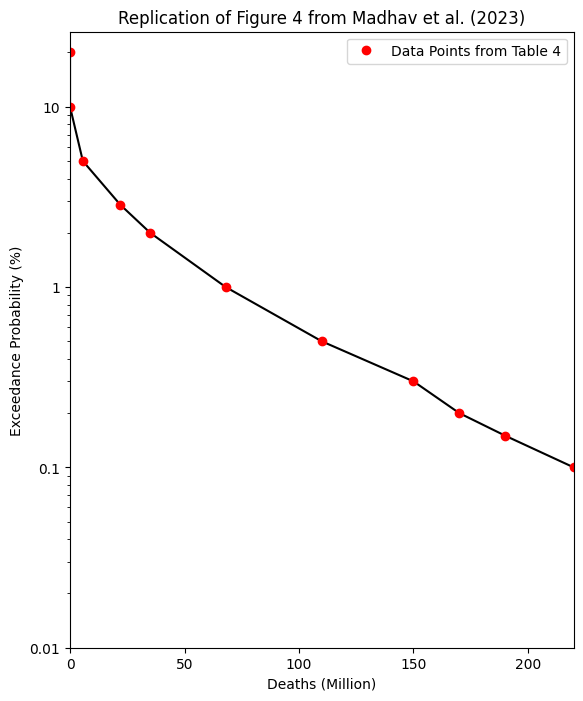

In [7]:
## Recreate Figure 4 from values in Table 4
death_count = [0.53, 1.4, 5600, 22000, 35000, 68000, 110000, 150000, 170000, 190000, 220000]
exceedance = [0.20, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

## Standardize units
death_count = [value / 1000 for value in death_count]  ## in million deaths
exceedance = [value * 100 for value in exceedance]  ## in %

## Create plot
plt.figure(figsize=(6.5, 8))

## Plot the data
plt.plot(death_count, exceedance, 'k-')  ## Black line
plt.plot(death_count, exceedance, 'ro', label='Data Points from Table 4')  ## Red dots

# Set y-axis scale and ticks
plt.yscale('log')
plt.yticks([0.01, 0.1, 1, 10], labels=['0.01', '0.1', '1', '10'])

## Set x-axis scale and ticks
plt.xlim(0,220)
plt.xticks([0, 50, 100, 150, 200])

## Label title and axes
plt.title('Replication of Figure 4 from Madhav et al. (2023)')
plt.xlabel('Deaths (Million)')
plt.ylabel('Exceedance Probability (%)')

## Display
plt.legend()
plt.show()

In [8]:
## Create Madhav exceedance from Table 4
severity = [0.001, 0.002, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
exceedance = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

df_madhav = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Save to exceedance results folder
df_madhav.to_excel(cleandata_dir / "exceedance_results" / "madhav_original.xlsx", index=False)


**Note:** There is an error in the second row of Table 5 in Madhav (2023).

In [9]:
# ## Create Madhav exceedance with values from Tables 4 & 5
# death_count_thousands_4 = [0.53, 1.4, 5600, 22000, 35000, 68000, 110000, 150000, 170000, 190000, 220000]
# exceedance_4 = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

# death_count_thousands_5 = [0.8, 80, 8000, 80000]
# exceedance_5 = [0.14, 0.068, 0.045, 0.008]

# ## Combine lists
# death_count = death_count_thousands_4 + death_count_thousands_5
# exceedance = exceedance_4 + exceedance_5

# ## Create severity in SMUs (deaths per 10,000) from 7.8 billion population (p.12)
# severity = [value / 780 for value in death_count]

# ## Create and store Madhav's exceedances
# df_madhav = pd.DataFrame({
#     "severity": severity,
#     "exceedance": exceedance
# })

# ## Sort and reset index
# df_madhav = df_madhav.sort_values(by='severity', ascending=True)
# df_madhav = df_madhav.reset_index(drop=True)

# ## Save to exceedance results folder
# df_madhav.to_excel(cleandata_dir / "exceedance_results" / "madhav_original.xlsx", index=False)

## 2. Calculate exceedance probabilities from Marani et al.

In [10]:
## Set severeity points automatically 
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
                15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
                200, 220, 230, 240, 250, 260, 270, 280]

## Set up severity points manually
# severity = df_madhav['severity']
# severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]


In [11]:
## Calculate exceedance probabilities
exceedance = arrival * (1 - genpareto.cdf(severity, *params))

df_marani = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani = df_marani.sort_values(by='severity', ascending=True)
df_marani = df_marani.reset_index(drop=True)


In [12]:
## Calculate return time of epidemics more severe than COVID-19
covid_exceedance = arrival * (1 - genpareto.cdf(9.173127, *params))
covid_return_time = round(1 / covid_exceedance, 2)

## Display return time
print(f'Return time of epidemics more severe than COVID-19: {covid_return_time} years')

Return time of epidemics more severe than COVID-19: 35.86 years


## 3. Visualize exceedance comparison

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.0, 300.0)

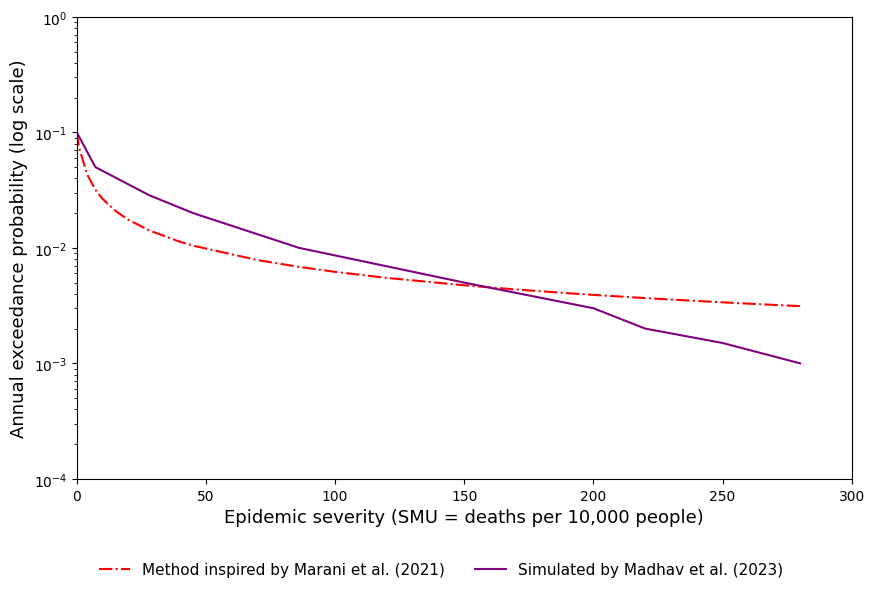

In [13]:
## Plot comparison across Marani et al. and Madhav et al. 
plt.figure(figsize=(10, 6))

## Plot for Marani
plt.plot(df_marani['severity'], df_marani['exceedance'], 
         color='red', linestyle='-.', label='Method inspired by Marani et al. (2021)')

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle='-', label='Simulated by Madhav et al. (2023)')

## Add labels and title
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis limits
plt.xlim(0, 300)

## Adding legend below the plot in 2 columns without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=2, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '03_resp_viral_comp.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


**Note:** The most extreme respiratory viral pandemic (the 1918 influenza pandemic) had a severity of 171 SMUs, while the second most extreme pandemic (the COVID-19 pandemic) only had a severity of 9.2 SMUs. The difference in magnitude and the lack of extreme pandemics with severities between the two may have resulted in a lower exceedance probability calibrated for epidemics 150 SMUs using Marani et al.'s historical data.